# Safe Haven Assets Post-COVID: An Empirical Assessment of Hedging Properties

**Course:** Empirical Methods in Finance
**Authors:** *[Names]*
**Date:** *[Date]*

---

## Abstract

*[To be written after results are finalized.]*


---

## 0. Imports & Setup

```bash
pip install numpy pandas matplotlib scipy statsmodels arch ruptures scikit-learn openpyxl
```

In [3]:
import subprocess
subprocess.run(['pip', 'install', 'arch', 'ruptures', 'scikit-learn'], capture_output=True)

import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import jarque_bera, kstest, norm
from scipy.optimize import minimize

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

from arch import arch_model
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import ruptures as rpt

warnings.filterwarnings('ignore')
np.random.seed(42)

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables',  exist_ok=True)

---

# 1. Data & Stylized Facts

## Step 1.1 — Data Loading & Sign Conventions

Six assets from `data/Data.xlsx`, daily prices. We compute log-returns with the following sign conventions so that **a positive value always represents a profit for a holder of the asset** (or, for safe havens vs USD, an appreciation against USD):

| Asset | Transformation |
|---|---|
| S&P 500, Eurostoxx 50, Gold | $\ln(P_t / P_{t-1})$ |
| US 10Y yield | $-\Delta y_t$ (yield up $\Rightarrow$ bond price down) |
| USDCHF, USDJPY | $-\ln(P_t / P_{t-1})$ (CHF/JPY appreciation as positive) |

Returns are multiplied by 100 so they are expressed in percentage points — keeps GARCH estimation numerically stable. The provisional pre/post split is set at **2020-03-01** and is later confirmed endogenously by Bai-Perron.

In [4]:
COLS = {
    'S&P500':             'SP500',
    'Eurostoxx 50':       'Eurostoxx50',
    'Gold':               'Gold',
    'US T 10-year Yield': 'US10Y',
    'USDCHF':             'USDCHF',
    'USDJPY':             'USDJPY',
}

raw = (pd.read_excel(Path("data/Data.xlsx"), index_col=0, parse_dates=True)
         [list(COLS.keys())]   # keep only the 6 needed columns
         .rename(columns=COLS)
         .ffill()
         .dropna())

returns = pd.DataFrame(index=raw.index)
returns['SP500']       = np.log(raw['SP500']       / raw['SP500'].shift(1))
returns['Eurostoxx50'] = np.log(raw['Eurostoxx50'] / raw['Eurostoxx50'].shift(1))
returns['Gold']        = np.log(raw['Gold']         / raw['Gold'].shift(1))
returns['US10Y']       = -raw['US10Y'].diff() / 100   # yield → bond return
returns['USDCHF']      = -np.log(raw['USDCHF'] / raw['USDCHF'].shift(1))
returns['USDJPY']      = -np.log(raw['USDJPY'] / raw['USDJPY'].shift(1))

returns = returns.dropna() * 100  # percentage points

split_date = "2020-03-01"
ret_pre  = returns.loc[:split_date]
ret_post = returns.loc[split_date:]

print(f"Full sample : {returns.index[0].date()} → {returns.index[-1].date()} ({len(returns)} obs)")
print(f"Pre-COVID   : {ret_pre.index[0].date()} → {ret_pre.index[-1].date()} ({len(ret_pre)} obs)")
print(f"Post-COVID  : {ret_post.index[0].date()} → {ret_post.index[-1].date()} ({len(ret_post)} obs)")

Full sample : 1990-01-03 → 2026-04-24 (9598 obs)
Pre-COVID   : 1990-01-03 → 2020-02-29 (7972 obs)
Post-COVID  : 2020-03-02 → 2026-04-24 (1626 obs)


## Step 1.2 — Descriptive Statistics

Annualized mean and volatility, skewness, **excess** kurtosis, max drawdown, and three diagnostic tests:

- **Jarque-Bera, Kolmogorov-Smirnov**: normality (we expect rejection — financial returns are not Gaussian).
- **ADF & KPSS**: stationarity (we expect ADF p < 0.05 and KPSS p > 0.05).
- **Ljung-Box on squared returns**: presence of ARCH effects (we expect very small p-values, justifying GARCH).

In [5]:
def stylized_facts(df):
    stats = pd.DataFrame(index=df.columns)
    stats['Mean (ann %)'] = df.mean() * 252
    stats['Vol (ann %)']  = df.std() * np.sqrt(252)
    stats['Skewness']     = df.skew()
    stats['Excess kurt']  = df.kurtosis()
    stats['Max DD %']     = ((1 + df / 100).cumprod() / (1 + df / 100).cumprod().cummax() - 1).min() * 100

    jb, ks, adf, kp, lb = [], [], [], [], []
    for col in df.columns:
        s = df[col].dropna()
        jb.append(jarque_bera(s)[1])
        ks.append(kstest(s, 'norm', args=(s.mean(), s.std()))[1])
        adf.append(adfuller(s)[1])
        kp.append(kpss(s, regression='c', nlags='auto')[1])
        lb.append(acorr_ljungbox(s**2, lags=[10], return_df=True)['lb_pvalue'].iloc[0])

    stats['JB p']   = jb
    stats['KS p']   = ks
    stats['ADF p']  = adf
    stats['KPSS p'] = kp
    stats['LB² p']  = lb
    return stats.round(4)

table1_pre  = stylized_facts(ret_pre)
table1_post = stylized_facts(ret_post)

print("Pre-COVID"); display(table1_pre)
print("Post-COVID"); display(table1_post)

table1_pre.to_csv('outputs/tables/table1_pre.csv')
table1_post.to_csv('outputs/tables/table1_post.csv')

Pre-COVID


,Mean (ann %),Vol (ann %),Skewness,Excess kurt,Max DD %,JB p,KS p,ADF p,KPSS p,LB² p
SP500,6.6564,17.0335,-0.2811,9.4036,-64.3329,0.0,0.0,0.0,0.1,0.000
Eurostoxx50,3.4971,20.4952,-0.1361,5.7252,-75.3244,0.0,0.0,0.0,0.1,0.000
Gold,4.3617,15.4366,-0.1939,8.5749,-48.2672,0.0,0.0,0.0,0.1,0.000
US10Y,0.2144,0.9142,-0.1386,2.5455,-2.8311,0.0,0.0,0.0,0.1,0.000
USDCHF,1.5525,11.2456,2.4204,75.1603,-40.9201,0.0,0.0,0.0,0.1,0.339
USDJPY,0.9616,10.4031,0.3778,5.6892,-46.5501,0.0,0.0,0.0,0.1,0.000


Post-COVID


,Mean (ann %),Vol (ann %),Skewness,Excess kurt,Max DD %,JB p,KS p,ADF p,KPSS p,LB² p
SP500,13.7311,20.2167,-0.6264,15.9229,-30.5669,0.0,0.0000,0.0,0.1000,0.0
Eurostoxx50,8.8236,19.8328,-0.8891,13.3454,-31.5502,0.0,0.0000,0.0,0.1000,0.0
Gold,16.8707,17.3737,-0.6637,6.3630,-23.3067,0.0,0.0000,0.0,0.0851,0.0
US10Y,-0.4885,0.9490,0.1276,2.4421,-4.3995,0.0,0.0019,0.0,0.1000,0.0
USDCHF,3.1979,7.8683,0.6148,4.3182,-13.7777,0.0,0.0002,0.0,0.1000,0.0
USDJPY,-6.0471,9.4441,0.4094,4.4996,-37.9168,0.0,0.0000,0.0,0.1000,0.0


## Step 1.3 — ACF of Returns and Squared Returns

If the ACF of $r_t$ is essentially noise but the ACF of $r_t^2$ shows strong, slowly-decaying autocorrelation, this is the visual signature of volatility clustering — the empirical motivation for GARCH. An additional argument from Lecture 9: even if we knew $\sigma_t^2$ exactly, using $r_t^2$ as a proxy would only fall within $\pm 50\%$ of the true variance about 26% of the time (under $\chi^2(1)$), so a model-based estimator is needed.

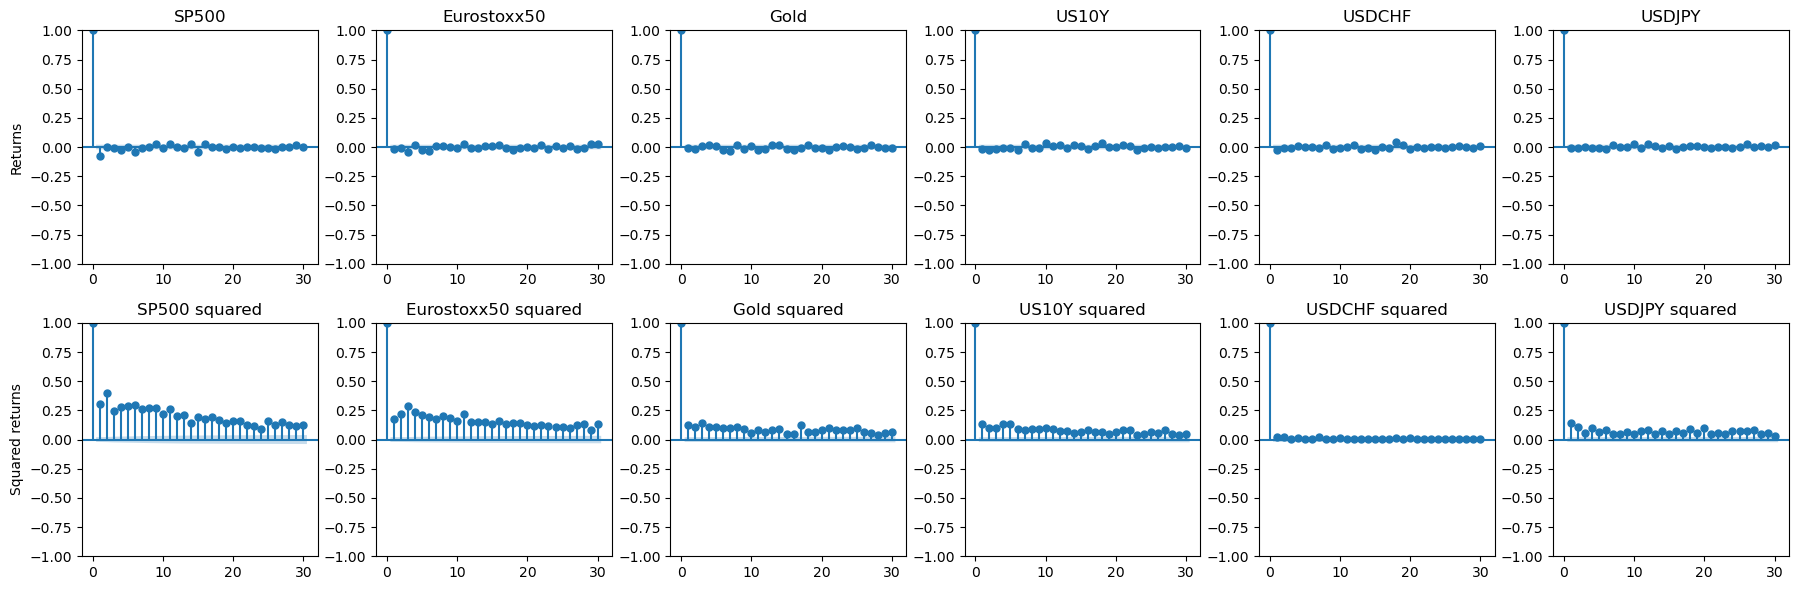

In [6]:
fig, axes = plt.subplots(2, len(returns.columns), figsize=(18, 6))
for i, col in enumerate(returns.columns):
    plot_acf(returns[col],     ax=axes[0, i], lags=30, title=col)
    plot_acf(returns[col] ** 2, ax=axes[1, i], lags=30, title=f"{col} squared")
axes[0, 0].set_ylabel('Returns')
axes[1, 0].set_ylabel('Squared returns')
plt.tight_layout()
plt.savefig('outputs/figures/acf.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 2. Univariate Volatility & Out-of-Sample Forecasting

We compare three volatility models on an out-of-sample period (post-2020):

1. **EWMA** (RiskMetrics) with $\varphi = 0.94$ — fully recursive, no estimated parameter.
2. **HAR** — daily/weekly/monthly OLS regression of realized variance.
3. **GJR-GARCH(1,1)-t** — captures clustering, leverage effect, and fat tails.

All three are estimated only on pre-2020 data and produce one-step-ahead forecasts on the post-2020 sample.


## Step 2.1 — Model Definitions

### EWMA

$$\sigma_t^2 = (1 - \varphi) r_{t-1}^2 + \varphi\, \sigma_{t-1}^2, \qquad \varphi = 0.94$$

Half-life $= \log(0.5) / \log(0.94) \approx 11$ days.

In [7]:
def ewma_variance(series, phi=0.94):
    var = np.zeros(len(series))
    var[0] = series.iloc[:30].var()
    for t in range(1, len(series)):
        var[t] = (1 - phi) * series.iloc[t-1]**2 + phi * var[t-1]
    return pd.Series(var, index=series.index)

### HAR

$$RV_{t+1} = c + \beta_d RV_t^{(d)} + \beta_w RV_t^{(w)} + \beta_m RV_t^{(m)} + u_{t+1}$$

where $RV^{(d)} = r_{t-1}^2$, $RV^{(w)}$ and $RV^{(m)}$ are the 5- and 22-day rolling means.

In [8]:
def har_features(series):
    rv = series ** 2
    return pd.DataFrame({
        'RV':   rv,
        'RV_d': rv.shift(1),
        'RV_w': rv.shift(1).rolling(5).mean(),
        'RV_m': rv.shift(1).rolling(22).mean(),
    }).dropna()

def fit_har(series_train):
    df = har_features(series_train)
    X  = sm.add_constant(df[['RV_d', 'RV_w', 'RV_m']])
    return sm.OLS(df['RV'], X).fit()

def predict_har(model, series_full):
    df = har_features(series_full)
    X  = sm.add_constant(df[['RV_d', 'RV_w', 'RV_m']])
    return pd.Series(model.predict(X), index=df.index)

### GJR-GARCH(1,1)-t

$$\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \gamma\,\varepsilon_{t-1}^2\,\mathbf{1}_{\{\varepsilon_{t-1}<0\}} + \beta\,\sigma_{t-1}^2, \qquad z_t \sim t_\nu$$

A positive and significant $\gamma$ is the empirical signature of the leverage effect.


## Step 2.2 — Estimate GJR-GARCH on Full Sample (for filtering) and on Pre/Post (for Table 2)

Two sets of estimates:
- **Full sample fit** → conditional volatility series used downstream (DCC inputs, beta decomposition).
- **Pre and post fits** → parameter comparison ($\gamma$, $\nu$, persistence) before vs. after COVID.

In [9]:
def fit_gjr(series):
    return arch_model(series, vol='GARCH', p=1, o=1, q=1, dist='studentst').fit(disp='off')

garch_full = {col: fit_gjr(returns[col]) for col in returns.columns}
garch_pre  = {col: fit_gjr(ret_pre[col])  for col in returns.columns}
garch_post = {col: fit_gjr(ret_post[col]) for col in returns.columns}

def garch_summary(model_dict, label):
    rows = []
    for col, res in model_dict.items():
        p = res.params
        rows.append({
            'omega': p['omega'], 'alpha': p['alpha[1]'], 'gamma': p['gamma[1]'],
            'beta':  p['beta[1]'], 'nu':    p['nu'],
            'persistence': p['alpha[1]'] + 0.5*p['gamma[1]'] + p['beta[1]'],
        })
    df = pd.DataFrame(rows, index=model_dict.keys()).round(4)
    df.columns = pd.MultiIndex.from_product([[label], df.columns])
    return df

table2 = pd.concat([garch_summary(garch_pre, 'Pre-COVID'),
                    garch_summary(garch_post, 'Post-COVID')], axis=1)
display(table2)
table2.to_csv('outputs/tables/table2_gjr_params.csv')

Pre-COVID                                             Post-COVID  \
                omega   alpha   gamma    beta      nu persistence      omega   
SP500          0.0124  0.0000  0.1639  0.9074  5.5134      0.9893     0.0271   
Eurostoxx50    0.0188  0.0151  0.1400  0.9027  6.7733      0.9879     0.0532   
Gold           0.0026  0.0685 -0.0406  0.9519  4.2978      1.0000     0.0364   
US10Y          0.0001  0.0500  0.0100  0.9250  8.4343      0.9800     0.0001   
USDCHF         0.0021  0.0416 -0.0087  0.9588  6.0449      0.9960     0.0172   
USDJPY         0.0030  0.0501 -0.0108  0.9500  5.0348      0.9946     0.0084   

                                                          
              alpha   gamma    beta       nu persistence  
SP500        0.0000  0.1894  0.8772   5.7254      0.9719  
Eurostoxx50  0.0029  0.2274  0.8432   5.1689      0.9598  
Gold         0.1067 -0.0723  0.9008   5.0849      0.9713  
US10Y        0.0500  0.0500  0.9050  12.0000      0.9800  
USDCHF       0.0583 -0.0092  0.8706   6.6951      0.9243  
USDJPY       0.1023 -0.0190  0.8872   4.6578      0.9800

### Figure — Conditional volatility (full-sample fit)

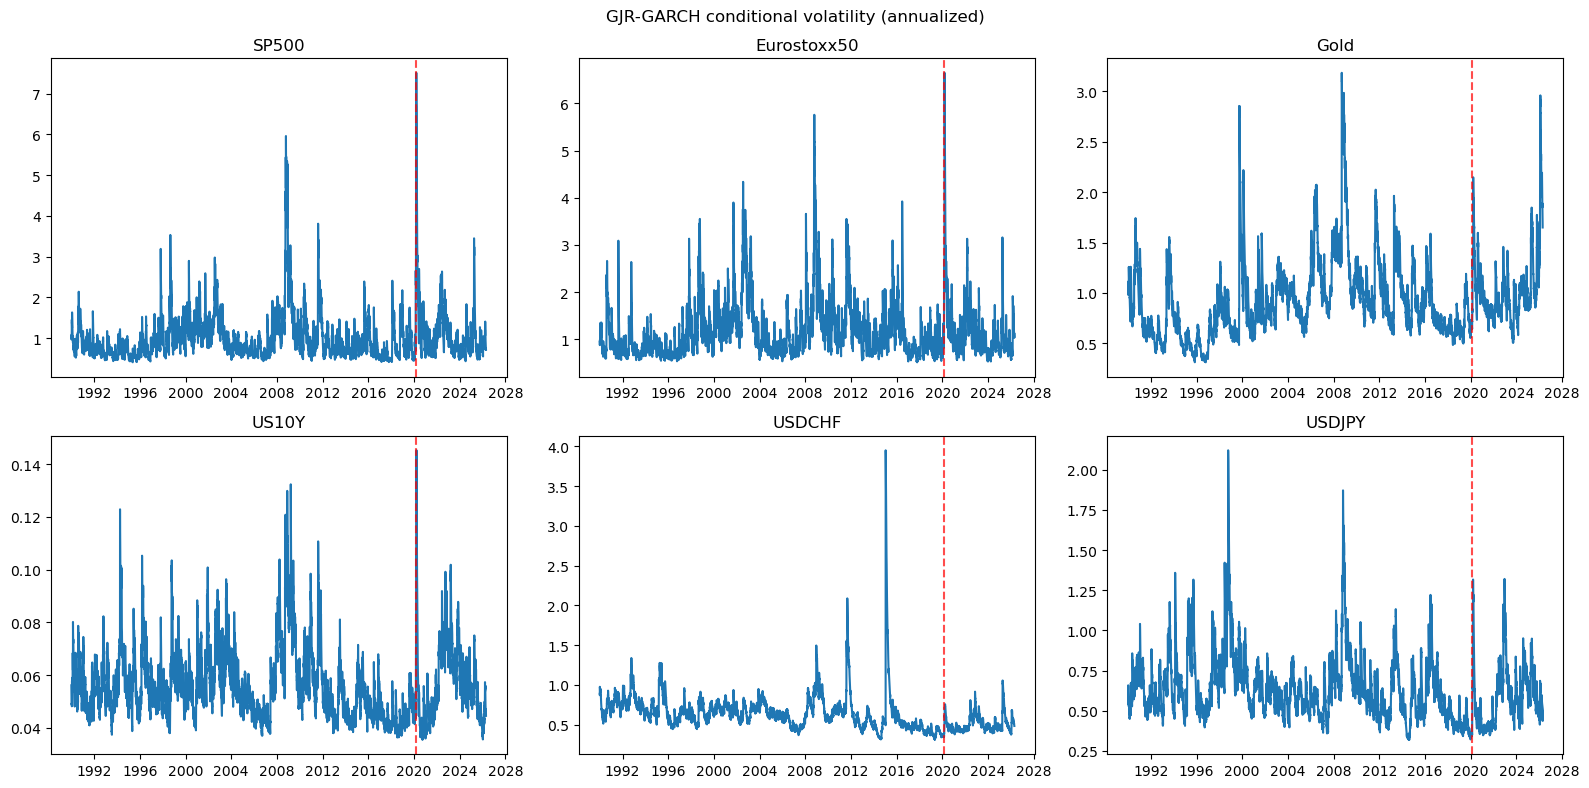

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, returns.columns):
    ax.plot(garch_full[col].conditional_volatility)
    ax.axvline(pd.to_datetime(split_date), color='red', linestyle='--', alpha=0.7)
    ax.set_title(col)
plt.suptitle('GJR-GARCH conditional volatility (annualized)')
plt.tight_layout()
plt.savefig('outputs/figures/conditional_vol.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2.3 — GARCH Diagnostics

Ljung-Box on squared standardized residuals at lag 10. A p-value above 0.05 means the GARCH has absorbed the autocorrelation in variance — the model is well specified.

In [11]:
print("Ljung-Box on squared standardized residuals (p > 0.05 = well specified)")
for col, res in garch_full.items():
    z2 = (res.resid / res.conditional_volatility).dropna() ** 2
    p  = acorr_ljungbox(z2, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
    print(f"  {col:10s}  p = {p:.4f}")

Ljung-Box on squared standardized residuals (p > 0.05 = well specified)
  SP500       p = 0.7815
  Eurostoxx50  p = 0.7509
  Gold        p = 0.0001
  US10Y       p = 0.4252
  USDCHF      p = 1.0000
  USDJPY      p = 0.5030


## Step 2.4 — Out-of-Sample Tournament

All three models are estimated on data **before** `2020-01-01`; we then produce one-step-ahead forecasts of the conditional variance over the post-2020 period and compare them on the realized variance proxy $r_t^2$.

- **EWMA**: recursive — needs no re-estimation, we just keep the post-cutoff values.
- **HAR**: OLS coefficients fitted on training data, applied to test-period lagged features.
- **GJR-GARCH**: we use `arch_model.fit(last_obs=...)` which estimates parameters on training data only; the filtered conditional volatility for subsequent dates uses these fixed parameters and the realized returns. This is a proper "fixed parameter expanding evaluation" OOS scheme.

Loss functions (Patton 2011, robust to the noisy proxy $r_t^2$):

$$L^{MSE}_t = (r_t^2 - \hat\sigma_t^2)^2, \qquad L^{QLIKE}_t = \frac{r_t^2}{\hat\sigma_t^2} - \ln\!\left(\frac{r_t^2}{\hat\sigma_t^2}\right) - 1$$

In [12]:
def qlike(actual, forecast):
    return actual / forecast - np.log(actual / forecast) - 1

def mse(actual, forecast):
    return (actual - forecast) ** 2

OOS_CUTOFF = '2020-01-01'

# GARCH refit with last_obs = OOS_CUTOFF
garch_oos = {col: arch_model(returns[col], vol='GARCH', p=1, o=1, q=1, dist='studentst')
                  .fit(last_obs=OOS_CUTOFF, disp='off')
             for col in returns.columns}

# HAR fit on training, predict on full series (we slice OOS portion later)
har_oos = {col: fit_har(returns[col].loc[:OOS_CUTOFF]) for col in returns.columns}

rows = []
for col in returns.columns:
    actual_var = (returns[col] ** 2).loc[OOS_CUTOFF:]
    garch_fc   = (garch_oos[col].conditional_volatility ** 2).loc[OOS_CUTOFF:]
    ewma_fc    = ewma_variance(returns[col]).loc[OOS_CUTOFF:]
    har_fc     = predict_har(har_oos[col], returns[col]).loc[OOS_CUTOFF:]

    df = pd.DataFrame({'A': actual_var, 'GARCH': garch_fc,
                       'EWMA': ewma_fc, 'HAR': har_fc}).dropna()

    rows.append({
        'Asset': col,
        'MSE GARCH':   mse(df['A'], df['GARCH']).mean(),
        'MSE EWMA':    mse(df['A'], df['EWMA']).mean(),
        'MSE HAR':     mse(df['A'], df['HAR']).mean(),
        'QLIKE GARCH': qlike(df['A'], df['GARCH']).mean(),
        'QLIKE EWMA':  qlike(df['A'], df['EWMA']).mean(),
        'QLIKE HAR':   qlike(df['A'], df['HAR']).mean(),
    })

table3 = pd.DataFrame(rows).set_index('Asset').round(4)
display(table3)
table3.to_csv('outputs/tables/table3_oos.csv')

,MSE GARCH,MSE EWMA,MSE HAR,QLIKE GARCH,QLIKE EWMA,QLIKE HAR
Asset,,,,,,
SP500,NaN,NaN,NaN,NaN,NaN,NaN
Eurostoxx50,NaN,NaN,NaN,NaN,NaN,NaN
Gold,NaN,NaN,NaN,NaN,NaN,NaN
US10Y,NaN,NaN,NaN,NaN,NaN,NaN
USDCHF,NaN,NaN,NaN,NaN,NaN,NaN
USDJPY,NaN,NaN,NaN,NaN,NaN,NaN


### Diebold-Mariano test

$DM = \bar d / (\hat\sigma_d / \sqrt T) \to \mathcal{N}(0, 1)$ where $d_t = L^A_t - L^B_t$. A negative DM means model A is more accurate; a small p-value rejects the null of equal accuracy.

In [13]:
def diebold_mariano(la, lb):
    d  = np.asarray(la) - np.asarray(lb)
    dm = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
    return dm, 2 * (1 - norm.cdf(abs(dm)))

pairs = [('GARCH', 'EWMA'), ('GARCH', 'HAR'), ('EWMA', 'HAR')]
dm_rows = []
for col in returns.columns:
    actual_var = (returns[col] ** 2).loc[OOS_CUTOFF:]
    fc = {
        'GARCH': (garch_oos[col].conditional_volatility ** 2).loc[OOS_CUTOFF:],
        'EWMA':  ewma_variance(returns[col]).loc[OOS_CUTOFF:],
        'HAR':   predict_har(har_oos[col], returns[col]).loc[OOS_CUTOFF:],
    }
    df = pd.DataFrame({'A': actual_var, **fc}).dropna()
    for a, b in pairs:
        stat, p = diebold_mariano(qlike(df['A'], df[a]), qlike(df['A'], df[b]))
        dm_rows.append({'Asset': col, 'Pair': f'{a} vs {b}',
                        'DM': round(stat, 3), 'p': round(p, 4)})

dm_table = pd.DataFrame(dm_rows).set_index(['Asset', 'Pair'])
display(dm_table)
dm_table.to_csv('outputs/tables/table3_dm.csv')

DM   p
Asset       Pair                 
SP500       GARCH vs EWMA NaN NaN
            GARCH vs HAR  NaN NaN
            EWMA vs HAR   NaN NaN
Eurostoxx50 GARCH vs EWMA NaN NaN
            GARCH vs HAR  NaN NaN
            EWMA vs HAR   NaN NaN
Gold        GARCH vs EWMA NaN NaN
            GARCH vs HAR  NaN NaN
            EWMA vs HAR   NaN NaN
US10Y       GARCH vs EWMA NaN NaN
            GARCH vs HAR  NaN NaN
            EWMA vs HAR   NaN NaN
USDCHF      GARCH vs EWMA NaN NaN
            GARCH vs HAR  NaN NaN
            EWMA vs HAR   NaN NaN
USDJPY      GARCH vs EWMA NaN NaN
            GARCH vs HAR  NaN NaN
            EWMA vs HAR   NaN NaN

---

# 3. Multivariate Dependence

We measure how the co-movement between each safe haven and the S&P 500 has evolved. Two complementary tools: a model-based DCC and a purely empirical rolling correlation.


## Step 3.1 — DCC (EWMA-Based, Two-Step)

We follow Engle (2002) in spirit but use the simpler RiskMetrics-style EWMA recursion for $Q_t$, which is equivalent to a DCC with $a = 1 - \lambda$ and $b = \lambda$ fixed at $\lambda = 0.94$:

$$Q_t = (1 - \lambda)\, u_{t-1} u_{t-1}^\top + \lambda\, Q_{t-1}, \qquad R_t = \operatorname{diag}(Q_t)^{-1/2}\, Q_t\, \operatorname{diag}(Q_t)^{-1/2}$$

The inputs $u_{i,t}$ are the standardized residuals of the univariate GJR-GARCH from Step 2.2.

In [14]:
std_resid = pd.DataFrame({
    col: garch_full[col].resid / garch_full[col].conditional_volatility
    for col in returns.columns
}).dropna()

def dcc_ewma(u, lam=0.94):
    u_arr = u.values
    T, N  = u_arr.shape
    Q     = np.cov(u_arr.T)
    R     = np.zeros((T, N, N))
    R[0]  = np.corrcoef(u_arr.T)
    for t in range(1, T):
        ut_1 = u_arr[t-1].reshape(-1, 1)
        Q = (1 - lam) * (ut_1 @ ut_1.T) + lam * Q
        d_inv = np.diag(1 / np.sqrt(np.diag(Q)))
        R[t]  = d_inv @ Q @ d_inv
    return R

R_dyn = dcc_ewma(std_resid)

market  = 'SP500'
m_idx   = list(returns.columns).index(market)
dcc_corr = pd.DataFrame(index=std_resid.index)
for col in returns.columns:
    if col != market:
        j = list(returns.columns).index(col)
        dcc_corr[col] = R_dyn[:, j, m_idx]

## Step 3.2 — Conditional Beta Decomposition

For each safe haven $j$:

$$\beta_{j,t} = \rho_{j,m,t}\,\frac{\sigma_{j,t}}{\sigma_{m,t}}$$

Decomposing $\beta$ into a **correlation channel** and a **relative-volatility channel** identifies whether a post-COVID change in beta comes from increased co-movement with the market or from a shift in the asset's risk profile.

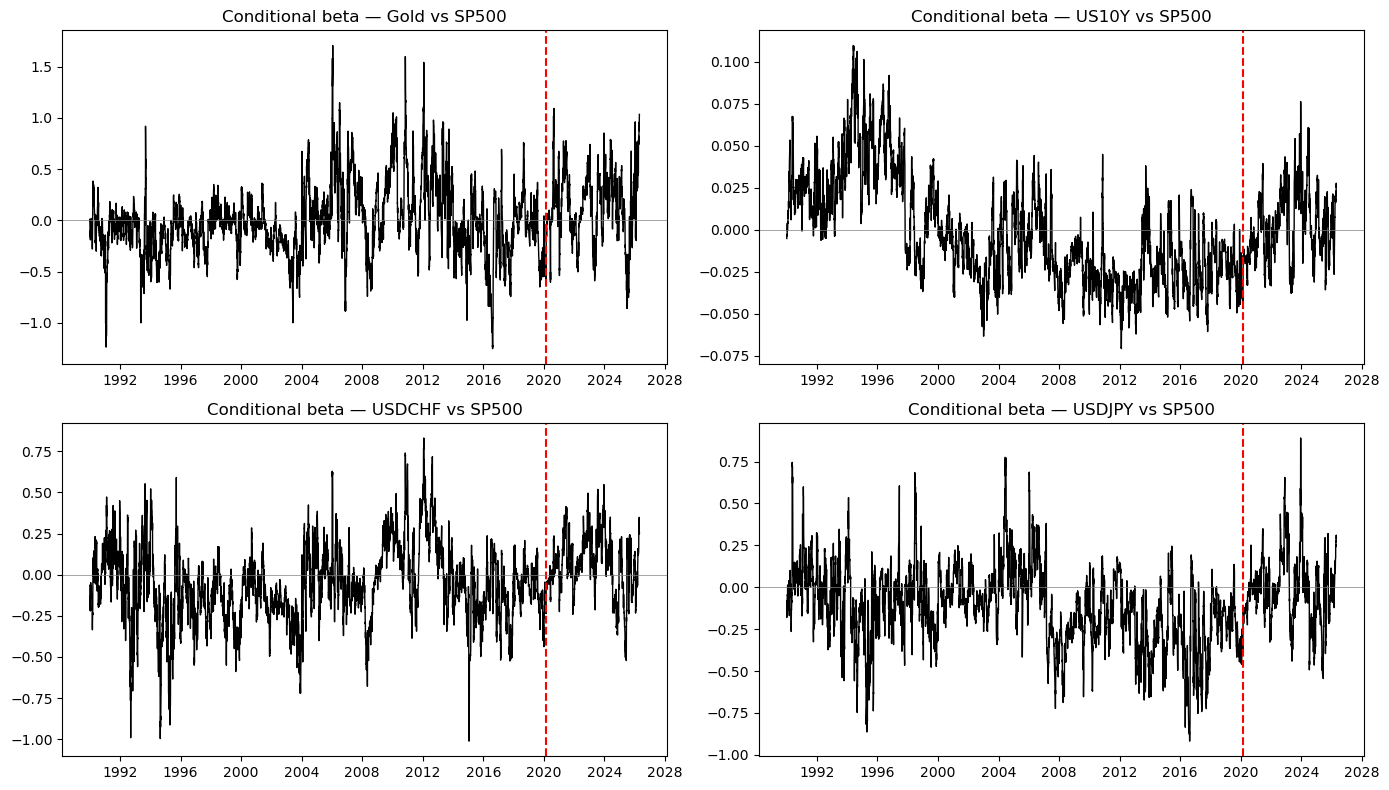

In [15]:
sigma_m  = garch_full[market].conditional_volatility.loc[std_resid.index]
dcc_beta = pd.DataFrame(index=std_resid.index)
for col in dcc_corr.columns:
    sigma_j = garch_full[col].conditional_volatility.loc[std_resid.index]
    dcc_beta[col] = dcc_corr[col] * (sigma_j / sigma_m)

safe_havens = ['Gold', 'US10Y', 'USDCHF', 'USDJPY']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, safe_havens):
    ax.plot(dcc_beta[col], color='black', linewidth=1)
    ax.axvline(pd.to_datetime(split_date), color='red', linestyle='--')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_title(f'Conditional beta — {col} vs SP500')
plt.tight_layout()
plt.savefig('outputs/figures/conditional_beta.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3.3 — Rolling 252-Day Correlation

A non-parametric counterpart to the DCC. If both series detect the same structural break in Section 4.2, the result is robust to the modeling choice.

In [16]:
rolling_corr = pd.DataFrame(index=returns.index)
for col in returns.columns:
    if col != market:
        rolling_corr[col] = returns[market].rolling(252).corr(returns[col])
rolling_corr = rolling_corr.dropna()

### Main figure: DCC vs rolling correlation

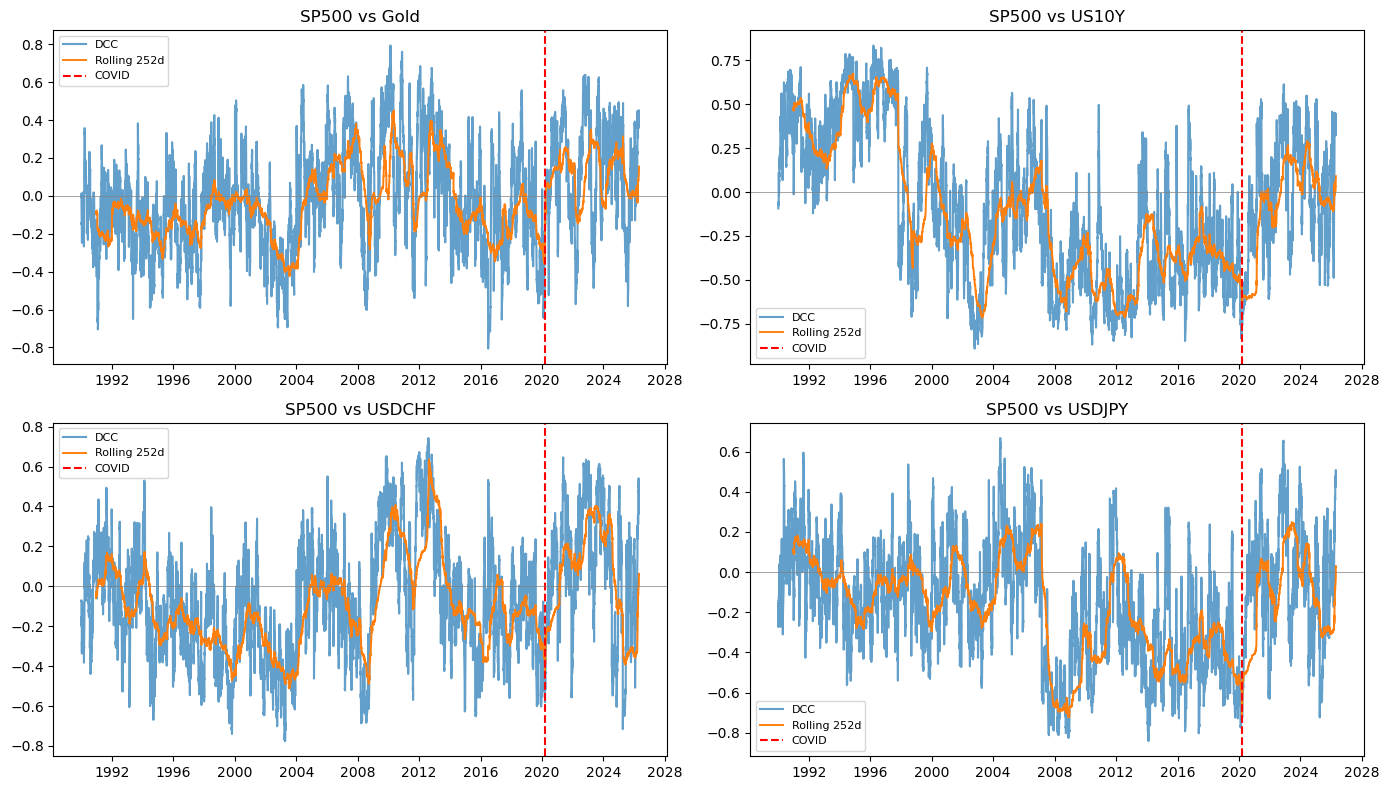

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, safe_havens):
    ax.plot(dcc_corr[col],    label='DCC',         alpha=0.7)
    ax.plot(rolling_corr[col], label='Rolling 252d', linewidth=1.4)
    ax.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='COVID')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_title(f'SP500 vs {col}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/figures/correlations.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 4. Structural Breaks & Regimes

## Step 4.1 — Rolling PCA

The share of variance explained by the first principal component on a rolling 252-day window:

$$V^{PC1}_t = \frac{\lambda_{1,t}}{\sum_k \lambda_{k,t}}$$

A rising $V^{PC1}$ means a single factor explains more of the cross-sectional return variation — the cross-asset universe behaves more like a single bet, and diversification weakens. We also report PC1 loadings pre vs post to see whether safe havens have moved closer to the dominant factor.

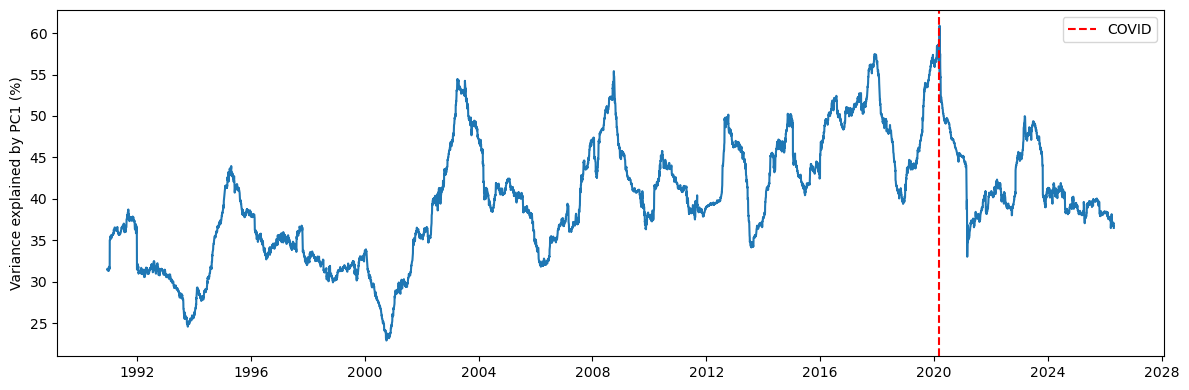

In [18]:
window = 252
v_pc1 = pd.Series(index=returns.index, dtype=float)

for t in range(window, len(returns)):
    chunk = returns.iloc[t - window:t]
    scaled = StandardScaler().fit_transform(chunk)
    pca = PCA(n_components=chunk.shape[1]).fit(scaled)
    v_pc1.iloc[t] = pca.explained_variance_ratio_[0]

v_pc1 = v_pc1.dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(v_pc1.index, v_pc1 * 100)
ax.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='COVID')
ax.set_ylabel('Variance explained by PC1 (%)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/rolling_vpc1.png', dpi=150, bbox_inches='tight')
plt.show()

### PC1 loadings pre / post

In [19]:
def pca_loadings(df):
    scaled = StandardScaler().fit_transform(df)
    pca    = PCA(n_components=df.shape[1]).fit(scaled)
    return pd.Series(pca.components_[0], index=df.columns)

loadings = pd.DataFrame({
    'Pre-COVID':  pca_loadings(ret_pre),
    'Post-COVID': pca_loadings(ret_post),
}).round(4)
display(loadings)
loadings.to_csv('outputs/tables/pca_loadings.csv')

,Pre-COVID,Post-COVID
SP500,-0.4505,-0.0319
Eurostoxx50,-0.4447,-0.0204
Gold,0.2721,0.4291
US10Y,0.3599,0.4675
USDCHF,0.4161,0.5337
USDJPY,0.4718,0.5577


## Step 4.2 — Bai-Perron

We let the data find the break dates rather than imposing them. The algorithm minimizes total SSR over admissible partitions with a minimum segment length of 252 days, and is applied to both the DCC and the rolling correlation series.

A short comment on **TAR** for the methodology section of the report: Lecture 12 introduced threshold autoregressive models as an alternative to Markov-switching, with regime transitions driven by an observable threshold. Their key limitation, noted in class, is that the persistence of the latent state is tied to the persistence of the threshold variable — too restrictive for our setting. We therefore rely on Markov-switching in Step 4.3.

In [20]:
def bai_perron(series, n_breaks=2, min_size=252):
    algo = rpt.Dynp(model="l2", min_size=min_size).fit(series.values.reshape(-1, 1))
    indices = algo.predict(n_bkps=n_breaks)
    return [series.index[i - 1] for i in indices[:-1]]

break_dates = {}
for col in safe_havens:
    for label, s in [('DCC', dcc_corr[col]), ('Rolling', rolling_corr[col])]:
        bd = bai_perron(s, n_breaks=2)
        break_dates[f'{col} ({label})'] = bd
        print(f"{col:8s} ({label}): {[d.date() for d in bd]}")

bp_table = pd.DataFrame(break_dates, index=['Break 1', 'Break 2']).T
display(bp_table)
bp_table.to_csv('outputs/tables/bai_perron_breaks.csv')

Gold     (DCC): [datetime.date(2004, 4, 13), datetime.date(2013, 8, 13)]
Gold     (Rolling): [datetime.date(2004, 8, 31), datetime.date(2014, 3, 31)]
US10Y    (DCC): [datetime.date(1997, 10, 27), datetime.date(2021, 2, 19)]
US10Y    (Rolling): [datetime.date(1998, 3, 26), datetime.date(2021, 5, 7)]
USDCHF   (DCC): [datetime.date(2009, 2, 17), datetime.date(2013, 5, 8)]
USDCHF   (Rolling): [datetime.date(2009, 7, 20), datetime.date(2013, 8, 14)]
USDJPY   (DCC): [datetime.date(2007, 3, 1), datetime.date(2020, 6, 23)]
USDJPY   (Rolling): [datetime.date(2007, 6, 7), datetime.date(2021, 2, 22)]


,Break 1,Break 2
Gold (DCC),2004-04-13,2013-08-13
Gold (Rolling),2004-08-31,2014-03-31
US10Y (DCC),1997-10-27,2021-02-19
US10Y (Rolling),1998-03-26,2021-05-07
USDCHF (DCC),2009-02-17,2013-05-08
USDCHF (Rolling),2009-07-20,2013-08-14
USDJPY (DCC),2007-03-01,2020-06-23
USDJPY (Rolling),2007-06-07,2021-02-22


## Step 4.3 — Markov-Switching (2-State)

Unlike Bai-Perron (permanent break), Markov-switching models recurring regimes. We fit a two-state model with switching mean and switching variance on each DCC correlation series, then re-fit separately on pre and post sub-samples to compare the persistence of the high-correlation regime ($p_{22}$ and the expected duration $1/(1-p_{22})$).

Practical note: unlike Bai-Perron, the Hamilton filter delivers today's regime probability in real time — useful for a portfolio manager who wants to adjust allocations as new data arrives.

In [21]:
def fit_ms(series):
    return MarkovRegression(series.dropna(), k_regimes=2,
                            trend='c', switching_variance=True).fit(disp=False)

ms_full = {col: fit_ms(dcc_corr[col])               for col in safe_havens}
ms_pre  = {col: fit_ms(dcc_corr[col].loc[:split_date])  for col in safe_havens}
ms_post = {col: fit_ms(dcc_corr[col].loc[split_date:]) for col in safe_havens}

### Table 4 — MS parameters pre / post

In [22]:
def ms_row(res, asset, period):
    p11 = res.regime_transition[0, 0, 0]
    p22 = res.regime_transition[1, 1, 0]
    return {'Asset': asset, 'Period': period,
            'p11': p11, 'p22': p22,
            'D1 (days)': 1 / (1 - p11),
            'D2 (days)': 1 / (1 - p22)}

table4 = pd.DataFrame([ms_row(ms_pre[c],  c, 'Pre')  for c in safe_havens] +
                      [ms_row(ms_post[c], c, 'Post') for c in safe_havens])
table4 = table4.set_index(['Asset', 'Period']).round(4)
display(table4)
table4.to_csv('outputs/tables/table4_ms_params.csv')

,,p11,p22,D1 (days),D2 (days)
Asset,Period,,,,
Gold,Pre,0.9840,0.9782,62.6089,45.7858
US10Y,Pre,0.9905,0.9920,105.0083,125.1204
USDCHF,Pre,0.9824,0.9850,56.8634,66.7999
USDJPY,Pre,0.9862,0.9847,72.6665,65.4567
Gold,Post,0.9803,0.9854,50.6951,68.2749
US10Y,Post,0.9835,0.9829,60.5779,58.3930
USDCHF,Post,0.9692,0.9766,32.5003,42.7907
USDJPY,Post,0.9789,0.9809,47.4810,52.3481


### Figure — Smoothed regime-2 probabilities

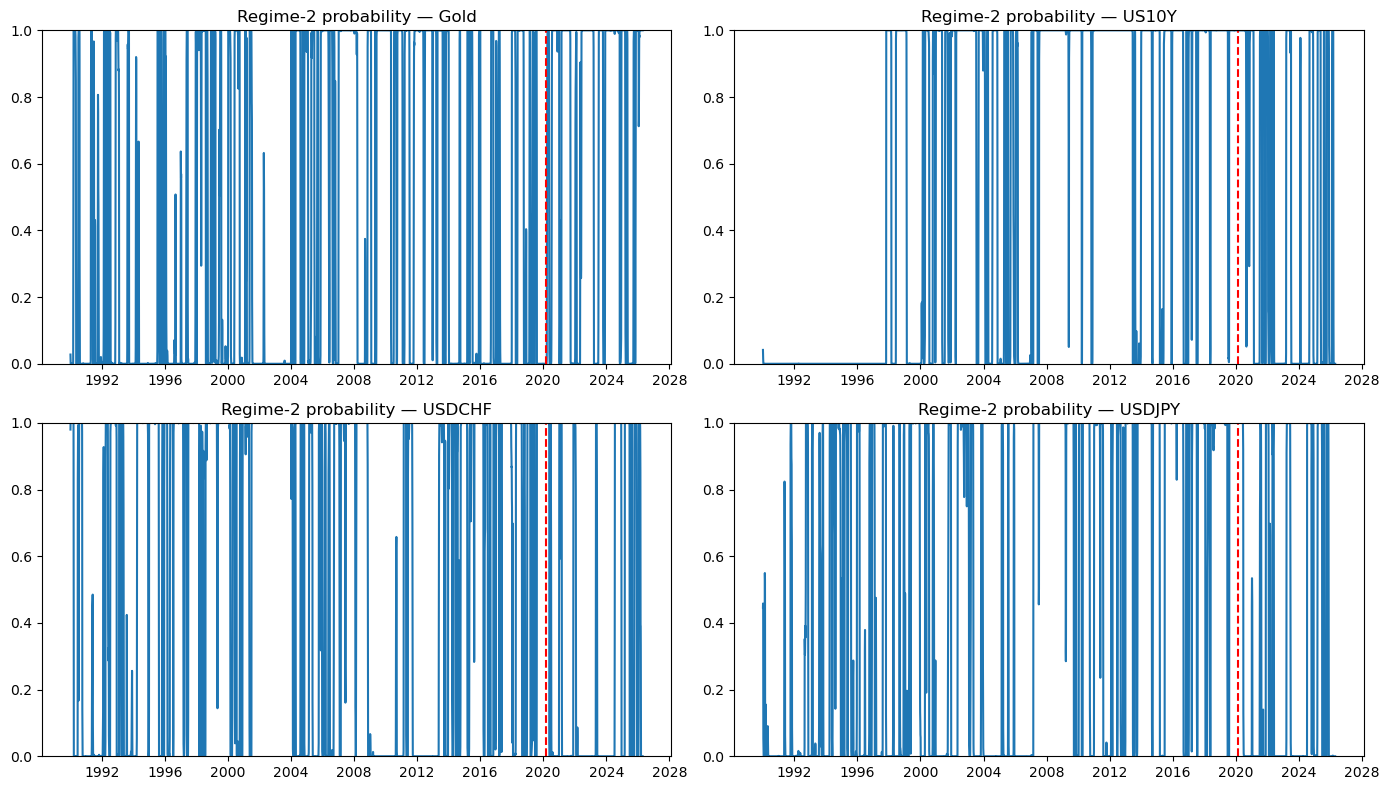

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, safe_havens):
    probs = ms_full[col].smoothed_marginal_probabilities[1]
    ax.plot(probs.index, probs)
    ax.axvline(pd.to_datetime(split_date), color='red', linestyle='--')
    ax.set_title(f'Regime-2 probability — {col}')
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('outputs/figures/smoothed_probs.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 5. Portfolio Construction

We translate the empirical results into portfolio terms. Two approaches:

- **ERC**: equal risk contribution — no expected returns required. Comparing the pre and post weights tells us how the risk-balanced allocation should have shifted.
- **Markowitz with constant $\mu$**: long-only minimum-variance optimization with a target return, weights bounded in $[0\%, 70\%]$, and $\mu$ held constant across regimes. This is the exact specification used in the Lecture 12 application and isolates the pure covariance effect.


## Step 5.1 — Equal Risk Contribution

Each asset contributes equally to total portfolio risk:

$$w_i \cdot \frac{(\Sigma w)_i}{\sqrt{w^\top \Sigma w}} = w_j \cdot \frac{(\Sigma w)_j}{\sqrt{w^\top \Sigma w}}, \qquad \forall\, i, j$$

Solved by minimizing the variance of risk contributions.

In [24]:
N      = returns.shape[1]
w0     = np.ones(N) / N
bounds = tuple((0.0, 0.70) for _ in range(N))

def erc_objective(w, cov):
    port_vol = np.sqrt(w @ cov @ w)
    mrc = (cov @ w) / port_vol
    rc  = w * mrc
    return ((rc - rc.mean()) ** 2).sum()

cons_sum = {'type': 'eq', 'fun': lambda w: w.sum() - 1.0}

cov_pre  = ret_pre.cov().values
cov_post = ret_post.cov().values

w_erc_pre  = minimize(erc_objective, w0, args=(cov_pre,),  bounds=bounds, constraints=cons_sum).x
w_erc_post = minimize(erc_objective, w0, args=(cov_post,), bounds=bounds, constraints=cons_sum).x

## Step 5.2 — Markowitz: Regime-Conditional Covariance

The covariance matrices used for Markowitz come from the **Markov-switching regimes** detected in Step 4.3. We use the smoothed probabilities of regime 2 from the Gold-vs-SP500 correlation (the most representative safe-haven signal) and classify each day as:

- Regime 1 (good hedge): $P(s_t = 2) < 0.3$
- Regime 2 (bad hedge): $P(s_t = 2) > 0.7$

Days in between are dropped to avoid mixing regimes.

Expected returns $\mu$ are the **unconditional sample means**, held constant across regimes — this isolates the impact of changing covariance on the optimal allocation.

In [25]:
prob_r2 = ms_full['Gold'].smoothed_marginal_probabilities[1]

r1_dates = prob_r2[prob_r2 < 0.3].index
r2_dates = prob_r2[prob_r2 > 0.7].index

cov_r1 = returns.loc[r1_dates].cov().values
cov_r2 = returns.loc[r2_dates].cov().values

mu_full    = returns.mean().values
target_ret = mu_full @ w0

cons_mark = [
    {'type': 'eq', 'fun': lambda w: w.sum() - 1.0},
    {'type': 'eq', 'fun': lambda w: w @ mu_full - target_ret},
]

def markowitz_objective(w, cov):
    return w @ cov @ w

w_mark_r1 = minimize(markowitz_objective, w0, args=(cov_r1,), bounds=bounds, constraints=cons_mark).x
w_mark_r2 = minimize(markowitz_objective, w0, args=(cov_r2,), bounds=bounds, constraints=cons_mark).x

## Step 5.3 — Performance Metrics & Table 5

For each allocation we compute annualized Sharpe ratio, maximum drawdown, and diversification ratio over the relevant sample (pre/post or regime 1/2).

In [26]:
def perf_metrics(w, returns_period):
    port = returns_period.values @ w
    mean = port.mean() * 252
    vol  = port.std()  * np.sqrt(252)
    sharpe = mean / vol
    eq = (1 + port / 100).cumprod()
    mdd = (eq / np.maximum.accumulate(eq) - 1).min()
    asset_vol = returns_period.std().values * np.sqrt(252)
    dr = (w @ asset_vol) / vol
    return {'Sharpe': sharpe, 'MDD %': mdd * 100, 'DR': dr}

rows = []
for label, w, ret_sub in [
    ('ERC pre',         w_erc_pre,  ret_pre),
    ('ERC post',        w_erc_post, ret_post),
    ('Markowitz reg1',  w_mark_r1,  returns.loc[r1_dates]),
    ('Markowitz reg2',  w_mark_r2,  returns.loc[r2_dates]),
]:
    m = perf_metrics(w, ret_sub)
    m['Allocation'] = label
    rows.append(m)

table5_perf    = pd.DataFrame(rows).set_index('Allocation').round(4)
table5_weights = pd.DataFrame({
    'ERC pre':        w_erc_pre,
    'ERC post':       w_erc_post,
    'Markowitz reg1': w_mark_r1,
    'Markowitz reg2': w_mark_r2,
}, index=returns.columns).round(4)

print("Weights")
display(table5_weights)
print("Performance")
display(table5_perf)

table5_weights.to_csv('outputs/tables/table5_weights.csv')
table5_perf.to_csv('outputs/tables/table5_perf.csv')

Weights


,ERC pre,ERC post,Markowitz reg1,Markowitz reg2
SP500,0.0543,0.0437,0.2085,0.2758
Eurostoxx50,0.0441,0.0439,0.0089,0.0000
Gold,0.0507,0.0417,0.2428,0.1689
US10Y,0.7000,0.7000,0.4801,0.5022
USDCHF,0.0673,0.0888,0.0596,0.0531
USDJPY,0.0836,0.0819,0.0000,0.0000


Performance


,Sharpe,MDD %,DR
Allocation,,,
ERC pre,0.4788,-7.3944,2.1792
ERC post,0.4323,-7.4358,1.7543
Markowitz reg1,0.4036,-18.8040,1.7558
Markowitz reg2,0.8393,-10.3198,1.3969
